In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('sealion_hero.png')

if image is None:
    print("Error: Image not found.")
else:   
    cv2.imshow('Original Image', image)

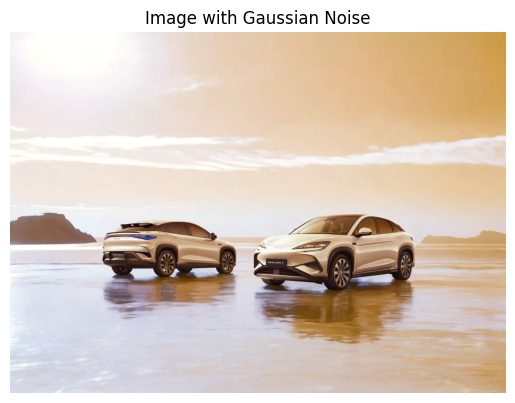

In [2]:
def add_gaussian_noise(image, mean=0, std=1):
    """
    Add Gaussian noise to an image.
    
    Parameters:
    - image: Input image (numpy array).
    - mean: Mean of the Gaussian noise.
    - var: Variance of the Gaussian noise.
    
    Returns:
    - Noisy image (numpy array).
    """
    gaussian_noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)  # Ensure pixel values are in [0, 255]
    return noisy_image

add_gaussian_noise(image, mean=0, std=25)
plt.imshow(image)
plt.title('Image with Gaussian Noise')
plt.axis('off')
plt.show()

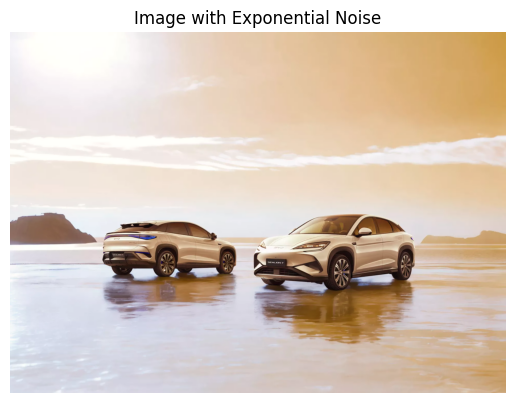

In [3]:
def add_exponential_noise(image, scale=1.0):
    """
    Add Exponential noise to an image.
    
    Parameters:
    - image: Input image (numpy array).
    - scale: Scale parameter of the Exponential distribution.
    
    Returns:
    - Noisy image (numpy array).
    """
    exponential_noise = np.random.exponential(scale, image.shape)
    noisy_image = image + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)  # Ensure pixel values are in [0, 255]
    return noisy_image

add_exponential_noise(image, scale=25.0)
plt.imshow(image)   
plt.title('Image with Exponential Noise')
plt.axis('off')
plt.show()

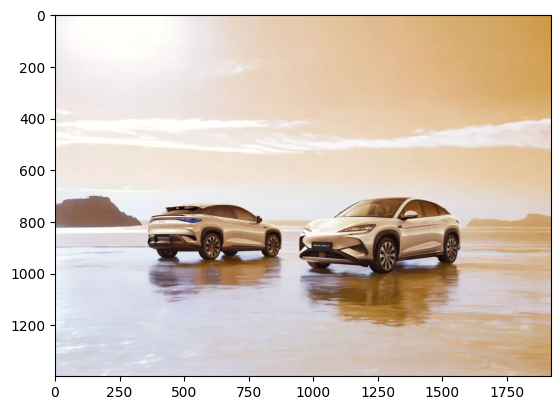

In [4]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05): 
    """ 
    Adds Salt & Pepper noise to an image. 
    Parameters: 
    - image: Input image to which noise will be added. 
    - salt_prob: Probability of adding salt (white) noise. 
    - pepper_prob: Probability of adding pepper (black) noise. Returns: 
    - noisy_image: Image with added Salt & Pepper noise. 
    """ 
    noisy_image = image.copy()
    num_salt = np.ceil(salt_prob * image.size) 
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape] 
    noisy_image[coords[0], coords[1]] = 255 
    
    num_pepper = np.ceil(pepper_prob * image.size) 
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape] 
    noisy_image[coords[0], coords[1]] = 0 
    return noisy_image


add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)
plt.imshow(image)


In [5]:
def add_uniform_noise(image, low=0, high=10): 
    """ 
        Adds Uniform noise to an image. 
        Parameters: 
        - image: Input image to which noise will be added. 
        - low: Lower bound of the uniform noise. 
        - high: Upper bound of the uniform noise. 
        Returns: 
        - noisy_image: Image with added Uniform noise. """ # Generate Uniform noise based on the shape of the image 
    uniform_noise = np.random.uniform(low, high, image.shape) # Add the noise to the original image and clip the result to stay within valid range 
    noisy_image = image + uniform_noise 
    noisy_image = np.clip(noisy_image, 0, 255)
    
    return noisy_image

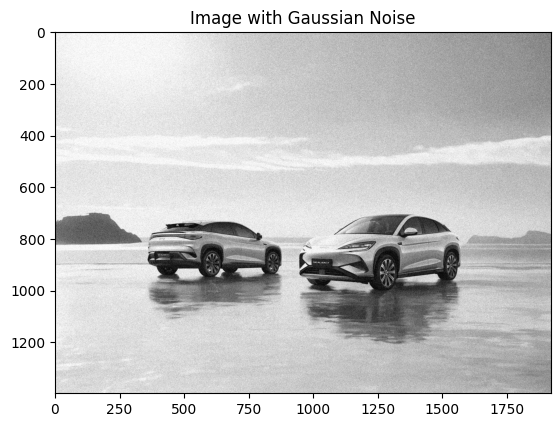

In [6]:
image_gray = cv2.imread('sealion_hero.png', cv2.IMREAD_GRAYSCALE)

noise_image = add_gaussian_noise(image_gray, mean=0, std=20)
plt.imshow(noise_image, cmap='gray') 
plt.title("Image with Gaussian Noise")
plt.show()

In [ ]:

def apply_box(image_input, box, filt_size):
    """
    Apply a box filter to an image.
    
    Parameters:
    - image_input: Input image (numpy array).
    - box: Box filter kernel (numpy array).
    - filt_size: Size of the filter (tuple).
    
    Returns:
    - Filtered image (numpy array).
    """
    pad_size = int(np.floor(filt_size / 2))
    image_padded = np.pad(image_input, pad_width=((pad_size, pad_size), (pad_size, pad_size)), mode='symmetric')
    
    image_box = copy.deepcopy(image_input)
    
    row, column = image_input.shape
    
    
    for i in range(row):
        for j in range(column):
            patch_curr = image_padded[i:i+filt_size, j:j+filt_size] 
            
            result_curr = box * patch_curr
            
            image_box[i, j] = np.sum(results_box)
    return image_box

: 